## Setup

In [ ]:
"""Written by AlchemYst-Crucible, the analysis architecture of AlkhemYst-Ai.

Not written by hand. Every step below corresponds to a component on the
pipeline canvas, and the settings it runs with are the ones set there, so the
canvas and this program cannot disagree about what was done.

The parts that are the same in every program, the metric and figure helpers
and the loader, come from tested code rather than being composed each time.
"""
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Seaborn, set once, for every figure this run produces.
#
# WHY A THEME RATHER THAN REWRITING EVERY PLOT
#
# There are around a hundred plotting calls across the generated code. Porting
# each to a seaborn function would be a hundred chances to change what a chart
# MEANS while trying to change how it looks, and the ones that break would
# break silently: a chart is still a chart when its axes are wrong.
#
# set_theme restyles all of them at once, because seaborn configures
# matplotlib's rcParams rather than replacing it. Existing plt calls keep
# working and come out looking like seaborn. The individual plots worth
# expressing in seaborn's own API, where it genuinely says something matplotlib
# cannot, are converted deliberately and one at a time.
#
# WHY THESE SETTINGS
#
#   whitegrid   a reader of a scientific figure follows a value to an axis,
#               and the gridline is what carries the eye. Darkgrid competes
#               with the data for contrast once a figure is printed.
#   colorblind  around one man in twelve cannot separate the default palette's
#               red and green. A figure that goes into a paper has to survive
#               that, and choosing it here means nobody has to remember.
#   notebook    sized for a figure read at a normal size rather than projected.
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="colorblind", context="notebook")
except Exception:
    # Never fatal. A missing seaborn should cost the styling, not the run:
    # the charts are the output the researcher came for.
    sns = None

ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)
METRICS = {}

# Preprocessing done to the dataframe before any model trains, recorded with
# the FITTED parameters so a deployed model can replay the exact same
# preparation on inference data (see the model bundle saved with each model).
PREP_STEPS = []
INPUT_SCHEMA = {}

def save_fig(name):
    plt.tight_layout()
    plt.savefig(ARTIFACTS / f"{name}.png", dpi=130)
    plt.close()

# ── Plot redundancy ──────────────────────────────────────────────────────────
#
# Every plot drawn here is one a reader has to look at. A generator that draws
# whatever it can, rather than whatever adds something, produces sections where
# most plots are variations of one another: a distribution for a column that
# holds one value, the same distribution twice for two columns that are copies,
# a histogram of a row identifier. The cost is not compute. It is that a report
# where most plots say nothing teaches the reader to skim, and the one plot
# that did carry a finding gets skimmed with the rest.
#
# So a plot has to earn its place: it is drawn when it shows something no plot
# already drawn shows. Judged on the variable and the question, not the chart
# type, since two different chart types can make the same point.
#
# Every refusal is recorded rather than silent. A missing plot with no
# explanation is indistinguishable from a bug, and the reasons are worth
# reading in their own right: "these two columns are identical" is a finding.
PLOTTED = {}          # signature -> the name of the plot that claimed it
PLOTS_SKIPPED = []    # {"plot": ..., "reason": ...}

def _skip_plot(name, reason):
    PLOTS_SKIPPED.append({"plot": name, "reason": reason})
    METRICS["plots_skipped"] = len(PLOTS_SKIPPED)
    return False

def claim_plot(name, signature):
    """Claim a plot signature. False means an earlier plot already showed it."""
    prior = PLOTTED.get(signature)
    if prior is not None:
        return _skip_plot(name, f"already shown by {prior}")
    PLOTTED[signature] = name
    return True

def distribution_is_worth_plotting(name, series, plotted_cols=None):
    """Is a distribution plot of this column worth drawing?

    Refuses four cases, each of which produces a picture with no information
    in it, and one that duplicates a picture already drawn.
    """
    s = series.dropna()
    if len(s) == 0:
        return _skip_plot(name, "column is entirely missing")
    nun = int(s.nunique())
    if nun <= 1:
        return _skip_plot(name, f"column holds a single value ({s.iloc[0]!r})")
    # An identifier: integer, one distinct value per row, and packed into a
    # dense range, which is what a row number or an accession looks like. A
    # histogram of it is a flat bar chart of the row count.
    #
    # The dtype and density conditions are both load-bearing. "One distinct
    # value per row" alone is true of ANY continuous measurement, since two
    # random floats are never equal, and the first version of this rule
    # suppressed every real measurement in the dataset while keeping nothing.
    # Caught by testing it against a frame with a known-good column in it.
    if nun == len(s) and len(s) > 20:
        try:
            is_int = bool(np.issubdtype(s.dtype, np.integer)) or bool((s == s.round()).all())
            span = float(s.max()) - float(s.min()) + 1.0
            dense = span > 0 and (len(s) / span) >= 0.9
        except Exception:
            is_int, dense = False, False
        if is_int and dense:
            return _skip_plot(name, "a dense run of unique integers, reads as an identifier rather than a measurement")
    # A near-copy of a column already plotted. Correlation rather than
    # equality, because a unit change or a rescale is still the same picture.
    if plotted_cols is not None:
        for other_name, other in plotted_cols.items():
            try:
                c = s.corr(other.dropna())
            except Exception:
                continue
            if c is not None and c == c and abs(float(c)) >= 0.995:
                return _skip_plot(name, f"same distribution as {other_name} (correlation {float(c):.3f})")
    return True

def emit_preview(nid, frame):
    # a small header of the data as it stands after this step, so the
    # UI can show the transformed table just like the source dataset
    prev = {
        "rows": int(len(frame)),
        "columns": int(frame.shape[1]),
        "sample_columns": [str(c) for c in frame.columns[:500]],
        "sample_truncated": bool(frame.shape[1] > 500),
        "sample": [
            {str(c): (None if pd.isna(v) else str(v)) for c, v in row.items()}
            for row in frame.iloc[:5, :500].to_dict(orient="records")
        ],
    }
    with open(ARTIFACTS / f"{nid}__preview.json", "w") as f:
        json.dump(prev, f, default=str)

# Build any sklearn estimator from a model node's label. The boosting
# libraries the user actually asked for (XGBoost/LightGBM/CatBoost) are used
# when installed in the run venv (requirements_for adds them for these
# labels); sklearn's HistGradientBoosting is only the fallback, so the
# reported algorithm matches the node. This is what makes each model node run
# the algorithm the user actually picked (Logistic Regression, SVM, KNN, ...)
# instead of a one-size-fits-all forest.

# Parameters set on a model node, applied to the estimator it chose.
#
# THE CANVAS IS NOT DECORATION.
#
# make_estimator was given the node's LABEL and nothing else. n_estimators,
# max_depth, learning_rate and subsample were typed into the panel, saved with
# the pipeline, shown again on reload, and discarded at the one moment they
# meant anything. Every model node on the platform ran on this function's own
# defaults, and the panel that displayed the user's value was reporting a
# setting that had never been used. Found by changing max_depth from 6 to 2 on
# a 600-row trial and getting metrics identical to the last decimal.
#
# Applied by asking the estimator what it accepts rather than by keeping a
# table per library: a parameter lands wherever the chosen estimator has a
# home for it, and where it has none the run SAYS SO rather than dropping it
# quietly. A setting that cannot take effect is worth more as a reported
# refusal than as a silent no-op, which is the whole lesson of the paragraph
# above.
_PARAM_ALIASES = {
    "n_estimators":      ("n_estimators", "iterations"),
    "max_depth":         ("max_depth", "depth"),
    "learning_rate":     ("learning_rate", "eta"),
    "subsample":         ("subsample", "bagging_fraction"),
    "random_seed":       ("random_state", "seed"),
    "random_state":      ("random_state", "seed"),
}
# Set on the node for the pipeline's benefit, not the estimator's.
_NOT_HYPERPARAMS = {"target", "targets", "features", "label", "group_col",
                    "test_size", "val_size", "stratify", "strategy"}

def apply_hyperparams(est, cfg, nid=None):
    if not cfg:
        return est
    try:
        accepted = est.get_params()
    except Exception:
        return est
    applied, ignored = {}, []
    for key, value in cfg.items():
        if key in _NOT_HYPERPARAMS or value is None or value == "":
            continue
        for cand in _PARAM_ALIASES.get(key, (key,)):
            if cand in accepted:
                try:
                    est.set_params(**{cand: value})
                    applied[cand] = value
                except Exception:
                    ignored.append(key)
                break
        else:
            ignored.append(key)
    if nid:
        if applied:
            METRICS[nid + "::hyperparameters"] = ", ".join(
                "%s=%s" % (k, v) for k, v in sorted(applied.items()))
        if ignored:
            # Named rather than swallowed: "this estimator has no subsample"
            # is a fact the person who set it needs, and the run is the only
            # place it can be told.
            METRICS[nid + "::hyperparameters_not_supported"] = ", ".join(
                sorted(set(ignored)))
    return est

def make_estimator(name, is_clf, cfg=None, nid=None):
    return apply_hyperparams(_base_estimator(name, is_clf), cfg, nid)

def _base_estimator(name, is_clf):
    n = str(name).lower()
    if "xgboost" in n or "xgb" in n:
        try:
            from xgboost import XGBClassifier, XGBRegressor
            return (XGBClassifier(n_estimators=300, random_state=42, eval_metric="logloss")
                    if is_clf else XGBRegressor(n_estimators=300, random_state=42))
        except ImportError:
            print("xgboost not installed in this environment -- using sklearn HistGradientBoosting instead")
    if "lightgbm" in n or "lgbm" in n:
        try:
            from lightgbm import LGBMClassifier, LGBMRegressor
            return (LGBMClassifier(n_estimators=300, random_state=42, verbosity=-1)
                    if is_clf else LGBMRegressor(n_estimators=300, random_state=42, verbosity=-1))
        except ImportError:
            print("lightgbm not installed in this environment -- using sklearn HistGradientBoosting instead")
    if "catboost" in n:
        try:
            from catboost import CatBoostClassifier, CatBoostRegressor
            return (CatBoostClassifier(iterations=300, random_state=42, verbose=False)
                    if is_clf else CatBoostRegressor(iterations=300, random_state=42, verbose=False))
        except ImportError:
            print("catboost not installed in this environment -- using sklearn HistGradientBoosting instead")
    if is_clf:
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
            HistGradientBoostingClassifier)
        from sklearn.tree import DecisionTreeClassifier
        from sklearn.neighbors import KNeighborsClassifier
        from sklearn.naive_bayes import GaussianNB
        from sklearn.svm import SVC
        from sklearn.neural_network import MLPClassifier
        if "logistic" in n: return LogisticRegression(max_iter=1000)
        if "extra" in n: return ExtraTreesClassifier(n_estimators=200, random_state=42)
        if "forest" in n and "isolation" not in n: return RandomForestClassifier(n_estimators=200, random_state=42)
        if "naive" in n or "bayes" in n: return GaussianNB()
        if "neighbor" in n or "knn" in n: return KNeighborsClassifier()
        if "svm" in n or "svc" in n or "support vector" in n: return SVC(probability=True, random_state=42)
        if "mlp" in n or "neural" in n or "perceptron" in n: return MLPClassifier(max_iter=400, random_state=42)
        if any(k in n for k in ("xgboost", "lightgbm", "catboost", "gradient", "boost")): return HistGradientBoostingClassifier(random_state=42)
        if "tree" in n: return DecisionTreeClassifier(random_state=42)
        return RandomForestClassifier(n_estimators=200, random_state=42)
    else:
        from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
        from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
            HistGradientBoostingRegressor)
        from sklearn.tree import DecisionTreeRegressor
        from sklearn.neighbors import KNeighborsRegressor
        from sklearn.svm import SVR
        from sklearn.neural_network import MLPRegressor
        if "ridge" in n: return Ridge()
        if "lasso" in n: return Lasso()
        if "elastic" in n: return ElasticNet()
        if "extra" in n: return ExtraTreesRegressor(n_estimators=200, random_state=42)
        if "forest" in n: return RandomForestRegressor(n_estimators=200, random_state=42)
        if "neighbor" in n or "knn" in n: return KNeighborsRegressor()
        if "svr" in n or "svm" in n or "support vector" in n: return SVR()
        if "mlp" in n or "neural" in n: return MLPRegressor(max_iter=400, random_state=42)
        if any(k in n for k in ("xgboost", "lightgbm", "catboost", "gradient", "boost")): return HistGradientBoostingRegressor(random_state=42)
        if "tree" in n: return DecisionTreeRegressor(random_state=42)
        if "linear" in n: return LinearRegression()
        return RandomForestRegressor(n_estimators=200, random_state=42)


IMAGE_SUFFIXES = (".png", ".jpg", ".jpeg", ".bmp", ".gif", ".webp", ".tif", ".tiff")


def find_images(root):
    """Every image in an extracted archive, in a stable order."""
    import os as _os
    out = []
    for dp, _dn, fn in _os.walk(root):
        if "__MACOSX" in dp:
            continue
        for f in fn:
            if f.startswith(".") or not f.lower().endswith(IMAGE_SUFFIXES):
                continue
            out.append(_os.path.join(dp, f))
    out.sort()
    return out


def describe_image_archive(root, imgs=None):
    """One row per image: class folder, dimensions, channels, size."""
    import os as _os
    imgs = find_images(root) if imgs is None else imgs

    # Pillow, then scikit-image, then neither. Dimensions are the most useful
    # columns, but an archive that can still be counted and grouped by class is
    # far better than a run that stops because one library is missing.
    reader, PILImage, skio = None, None, None
    try:
        from PIL import Image as PILImage
        reader = "pil"
    except Exception:
        try:
            from skimage import io as skio
            reader = "skimage"
        except Exception:
            print("neither Pillow nor scikit-image is available; "
                  "describing the collection without pixel dimensions", flush=True)

    rows = []
    for f in imgs:
        rel = _os.path.normpath(_os.path.relpath(f, root))
        parts = rel.split(_os.sep)
        row = {
            "file": _os.path.basename(f),
            # The directory holding the image, when the archive is arranged
            # that way. Relative to the extraction root, so it is the
            # researcher's folder name and not a temp path.
            "folder": parts[-2] if len(parts) > 1 else "",
            "size_bytes": int(_os.path.getsize(f)),
        }
        if reader == "pil":
            try:
                with PILImage.open(f) as im:
                    row["width"], row["height"] = int(im.width), int(im.height)
                    row["mode"] = str(im.mode)
                    row["channels"] = len(im.getbands())
            except Exception:
                pass
        elif reader == "skimage":
            try:
                a = skio.imread(f)
                row["height"], row["width"] = int(a.shape[0]), int(a.shape[1])
                row["channels"] = int(a.shape[2]) if a.ndim > 2 else 1
            except Exception:
                pass
        rows.append(row)

    frame = pd.DataFrame(rows)
    if "width" in frame.columns and "height" in frame.columns:
        frame["aspect_ratio"] = (frame["width"] / frame["height"]).round(4)
        frame["pixels"] = frame["width"] * frame["height"]
    return frame, imgs, reader


def draw_collection_figures(frame, imgs, root, prefix="", reader="pil"):
    """A contact sheet and the two panels the generic pass will not draw.

    Both go through claim_plot, so when a canvas carries two EDA nodes the
    second does not redraw the first's figures. Every node still writes its own
    preview and metrics, because those are per-node data rather than a repeated
    picture; it is the identical figure appearing twice in a report that
    teaches a reader to skim.
    """
    import os as _os
    tag = (str(prefix) + "__") if prefix else ""

    try:
        import matplotlib.image as _mpimg
        k = min(12, len(imgs))
        # The archive is the same for every node on the canvas, so the
        # signature is the archive rather than anything about this node.
        if k and reader and claim_plot(tag + "collection_contact_sheet",
                                       ("collection_contact_sheet", len(imgs))):
            cols = min(6, k)
            rowsn = (k + cols - 1) // cols
            fig, axes = plt.subplots(rowsn, cols, figsize=(2.0 * cols, 2.2 * rowsn))
            flat = axes.ravel() if hasattr(axes, "ravel") else [axes]
            # Spread across the archive rather than the first twelve, which in
            # a class-sorted folder would all be one class.
            step = max(1, len(imgs) // k)
            for j in range(len(flat)):
                flat[j].set_xticks([]); flat[j].set_yticks([])
                if j >= k:
                    flat[j].axis("off"); continue
                fp = imgs[j * step]
                try:
                    flat[j].imshow(_mpimg.imread(fp))
                except Exception:
                    flat[j].axis("off"); continue
                lbl = _os.path.normpath(_os.path.relpath(fp, root)).split(_os.sep)
                flat[j].set_title(("%s/" % lbl[-2] if len(lbl) > 1 else "") + lbl[-1][:16],
                                  fontsize=7)
            plt.suptitle("Image collection: %d images" % len(imgs), fontsize=10)
            save_fig(tag + "collection_contact_sheet")
    except Exception as e:
        print("contact sheet skipped:", e, flush=True)

    try:
        panels = []
        if "folder" in frame.columns and frame["folder"].nunique() > 1:
            panels.append("classes")
        if "width" in frame.columns and frame[["width", "height"]].drop_duplicates().shape[0] > 1:
            panels.append("sizes")
        elif "width" in frame.columns and len(frame):
            print("every image is %dx%d" % (int(frame["width"].iloc[0]), int(frame["height"].iloc[0])),
                  flush=True)
        if panels and claim_plot(tag + "collection_overview",
                                 ("collection_overview", tuple(panels), len(imgs))):
            fig, ax = plt.subplots(1, len(panels), figsize=(5.4 * len(panels), 4.0))
            ax = [ax] if len(panels) == 1 else list(ax)
            for a, which in zip(ax, panels):
                if which == "classes":
                    vc = frame["folder"].value_counts()
                    a.bar(range(len(vc)), vc.values)
                    a.set_xticks(range(len(vc)))
                    a.set_xticklabels([str(x)[:14] for x in vc.index], rotation=30, ha="right", fontsize=8)
                    a.set_ylabel("images")
                    # An imbalance is what a class count exists to reveal, so
                    # it is stated rather than left to be read off the bars.
                    a.set_title("Images per class (%d to %d)" % (int(vc.min()), int(vc.max())))
                else:
                    a.scatter(frame["width"], frame["height"], s=26, alpha=0.6)
                    a.set_xlabel("width (px)"); a.set_ylabel("height (px)")
                    a.set_title("Image dimensions (%d distinct)"
                                % frame[["width", "height"]].drop_duplicates().shape[0])
            save_fig(tag + "collection_overview")
    except Exception as e:
        print("collection overview skipped:", e, flush=True)

## Dataset

In [ ]:
print("[[step]] n1787659832364 start 1/3 ▶ Drawing: Dataset", flush=True)

import glob as _g, zipfile as _z, tempfile as _t
_szz = _g.glob("data/*.zip")
if not _szz:
    print("Dataset found no image archive under data/; the vision steps below will report what they need", flush=True)
    METRICS["n1787659832364::status"] = "no image archive found"
else:
    _sxd = _t.mkdtemp()
    with _z.ZipFile(_szz[0]) as _szf:
        _szf.extractall(_sxd)
    _simgs = find_images(_sxd)
    if not _simgs:
        print("the archive holds no images", flush=True)
        METRICS["n1787659832364::status"] = "archive holds no images"
    else:
        _sdf, _simgs, _srd = describe_image_archive(_sxd, _simgs)
        METRICS["n1787659832364::images"] = int(len(_sdf))
        if "folder" in _sdf.columns:
            METRICS["n1787659832364::classes"] = int(_sdf["folder"].nunique())
            print("brought in %d images across %d classes"
                  % (len(_sdf), _sdf["folder"].nunique()), flush=True)
        else:
            print("brought in %d images" % len(_sdf), flush=True)
        emit_preview("n1787659832364", _sdf)

print("[[step]] n1787659832364 done 1/3 ✓ Dataset", flush=True)

## Image Features

In [ ]:
print("[[step]] n1787659846051 start 2/3 ▶ Tempering: Image Features", flush=True)
_CFG = {'backbone': 'resnet50', 'pretrained': False, 'epochs': 5, 'batch': 16, 'img': 224, 'lr': 0.001, 'device_pref': 'cpu', 'nid': 'n1787659846051', 'max_images': 1000, 'threshold': 'otsu', 'min_area': 20, 'invert': False, 'weights': 'yolov8n.pt', 'confidence': 0.25, 'cell_model': 'cyto3', 'diameter': None, 'copies': 5, 'similarity_threshold': 0.92, 'split_test': 0.2, 'split_seed': 42, 'split_nid': '', 'aug_intensity': False, 'aug_elastic': False}

import os, glob, zipfile, tempfile, sys
import numpy as np

# Libraries fetched on demand for this run, if any.
#
# APPENDED, so site-packages is searched first and the runner's own torch,
# numpy and scipy keep winning. Setting this as PYTHONPATH instead put it
# ahead of site-packages, and an on-demand scipy then shadowed the working one
# and failed to load, taking the run with it.
_vlibs = os.environ.get("ALKHEMYST_VISION_LIBS")
if _vlibs and _vlibs not in sys.path:
    sys.path.append(_vlibs)

_zips = glob.glob("data/*.zip")
if not _zips:
    raise SystemExit("this component needs a .zip of images as its dataset")
_root = tempfile.mkdtemp()
with zipfile.ZipFile(_zips[0]) as _zf:
    _zf.extractall(_root)

_EXT = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
def _images_under(base, exclude=()):
    out = []
    for _dp, _dn, _fn in os.walk(base):
        # Skip the junk archive tools leave behind, which otherwise appear as
        # images and fail to open halfway through a run.
        if "__MACOSX" in _dp or os.path.basename(_dp).startswith("."):
            continue
        if any(x in _dp.split(os.sep) for x in exclude):
            continue
        for _f in sorted(_fn):
            if _f.lower().endswith(_EXT) and not _f.startswith("."):
                out.append(os.path.join(_dp, _f))
    return sorted(out)

_files = _images_under(_root)
if not _files:
    raise SystemExit("no images found in the archive (expected %s)" % ", ".join(_EXT))
_LIMIT = int(_CFG.get("max_images") or 500)
if len(_files) > _LIMIT:
    print("%d images found, using the first %d (raise max_images to use more)" % (len(_files), _LIMIT))
    _files = _files[:_LIMIT]
_nid = _CFG.get("nid") or "cv"
METRICS["images"] = len(_files)

import torch, pandas as pd
from PIL import Image
from torchvision import transforms, models

_dev_pref = _CFG.get("device_pref") or "cpu"
DEVICE = torch.device("cuda" if (torch.cuda.is_available() and _dev_pref == "gpu") else "cpu")
_size = int(_CFG.get("img") or 224)

_name = str(_CFG.get("backbone") or "resnet18")
_builders = {
    "resnet18": models.resnet18, "resnet50": models.resnet50,
    "efficientnet_b0": models.efficientnet_b0, "densenet121": models.densenet121,
}
_fn = _builders.get(_name, models.resnet18)
try:
    _net = _fn(weights="DEFAULT")
    METRICS["pretrained"] = True
except Exception as _e:
    # No network on the runner, or the weight cache is cold. Random features
    # are near useless, so this says so loudly rather than producing a CSV
    # that looks fine and predicts nothing.
    print("pretrained weights unavailable (%s): features will be near random" % type(_e).__name__)
    _net = _fn(weights=None)
    METRICS["pretrained"] = False

# Replace the classifier head with identity: we want the representation, not
# somebody else's thousand ImageNet classes.
if hasattr(_net, "fc"):
    _dim = _net.fc.in_features; _net.fc = torch.nn.Identity()
elif hasattr(_net, "classifier"):
    _c = _net.classifier
    _dim = (_c[-1] if isinstance(_c, torch.nn.Sequential) else _c).in_features
    _net.classifier = torch.nn.Identity()
else:
    _dim = 512
_net = _net.to(DEVICE).eval()

_tf = transforms.Compose([
    transforms.Resize((_size, _size)), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

_vecs, _names, _labels = [], [], []
with torch.no_grad():
    for _i in range(0, len(_files), 32):
        _batch = _files[_i:_i + 32]
        _t = torch.stack([_tf(Image.open(f).convert("RGB")) for f in _batch]).to(DEVICE)
        _vecs.append(_net(_t).cpu().numpy())
        for f in _batch:
            _names.append(os.path.basename(f))
            # The parent folder is the label when the archive is organised that
            # way, which is the convention the classifier already expects. It
            # travels into the CSV so a downstream model has a target.
            _labels.append(os.path.basename(os.path.dirname(f)))

_X = np.vstack(_vecs)
_df_feat = pd.DataFrame(_X, columns=["f%03d" % i for i in range(_X.shape[1])])
_df_feat.insert(0, "image", _names)
if len(set(_labels)) > 1:
    _df_feat.insert(1, "label", _labels)
_df_feat.to_csv(ARTIFACTS / (_nid + "__features.csv"), index=False)

METRICS["feature_dim"] = int(_X.shape[1])
METRICS["backbone"] = _name
if len(set(_labels)) > 1:
    METRICS["classes"] = len(set(_labels))
    from sklearn.decomposition import PCA
    _p = PCA(n_components=2).fit_transform(_X)
    plt.figure(figsize=(6.5, 5))
    for _c in sorted(set(_labels)):
        _m = [i for i, l in enumerate(_labels) if l == _c]
        plt.scatter(_p[_m, 0], _p[_m, 1], s=14, label=_c, alpha=0.75)
    plt.legend(fontsize=8); plt.title("%s embeddings, PCA" % _name)
    save_fig(_nid + "__embedding_pca")
for _k in ("feature_dim", "backbone", "images", "pretrained"):
    METRICS[_nid + "::" + _k] = METRICS.get(_k)

print("[[step]] n1787659846051 done 2/3 ✓ Image Features", flush=True)

## Near-Duplicate Audit

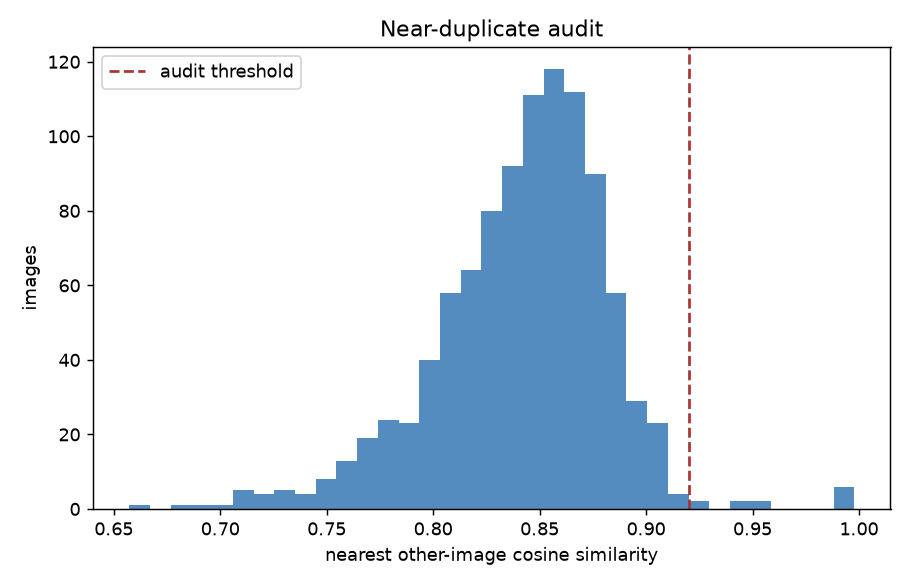

In [ ]:
print("[[step]] n_kvasir_near_duplicate_audit start 3/3 ▶ Tempering: Near-Duplicate Audit", flush=True)
_CFG = {'backbone': 'simple_cnn', 'pretrained': False, 'epochs': 5, 'batch': 16, 'img': 64, 'lr': 0.001, 'device_pref': 'cpu', 'nid': 'n_kvasir_near_duplicate_audit', 'max_images': 500, 'threshold': 'otsu', 'min_area': 20, 'invert': False, 'weights': 'yolov8n.pt', 'confidence': 0.25, 'cell_model': 'cyto3', 'diameter': None, 'copies': 5, 'similarity_threshold': 0.92, 'split_test': 0.2, 'split_seed': 42, 'split_nid': '', 'aug_intensity': False, 'aug_elastic': False}

if "_X" not in globals() or "_names" not in globals():
    raise RuntimeError("Near-Duplicate Audit needs an upstream Image Features node")
if not METRICS.get("pretrained"):
    raise RuntimeError(
        "Near-Duplicate Audit requires pretrained Image Features. The runner could not load the "
        "backbone weights, so random embeddings would make a false leakage finding."
    )

_threshold = float(_CFG.get("similarity_threshold") or 0.92)
_threshold = min(0.999, max(0.8, _threshold))
_split_repetitions = max(1, min(100, int(_CFG.get("split_seed_count") or 25)))
_norms = np.linalg.norm(_X, axis=1, keepdims=True)
_unit = _X / np.maximum(_norms, 1e-12)
_similarity = _unit @ _unit.T
np.fill_diagonal(_similarity, -1.0)
_rows, _parent = [], list(range(len(_names)))

def _find(_i):
    while _parent[_i] != _i:
        _parent[_i] = _parent[_parent[_i]]
        _i = _parent[_i]
    return _i

def _join(_a, _b):
    _a, _b = _find(_a), _find(_b)
    if _a != _b:
        _parent[_b] = _a

for _i in range(len(_names)):
    for _j in range(_i + 1, len(_names)):
        _score = float(_similarity[_i, _j])
        if _score >= _threshold:
            _join(_i, _j)
            _rows.append({"image_a": _names[_i], "image_b": _names[_j], "cosine_similarity": _score})

_members = {}
for _i in range(len(_names)):
    _members.setdefault(_find(_i), []).append(_i)
_groups = [g for g in _members.values() if len(g) > 1]
_cluster_for = {}
for _cluster, _group in enumerate(_groups, start=1):
    for _i in _group:
        _cluster_for[_i] = _cluster

_clusters = pd.DataFrame([{
    "image": _names[_i], "cluster": _cluster_for.get(_i, -1),
    "nearest_cosine_similarity": float(_similarity[_i].max()),
} for _i in range(len(_names))])
_clusters.to_csv(ARTIFACTS / (_CFG["nid"] + "__near_duplicate_clusters.csv"), index=False)
_pairs = pd.DataFrame(_rows, columns=["image_a", "image_b", "cosine_similarity"])
_pairs.sort_values("cosine_similarity", ascending=False).to_csv(
    ARTIFACTS / (_CFG["nid"] + "__near_duplicate_pairs.csv"), index=False)

# The Kvasir paper reports 80/10/10 but not a split seed or group rule. We
# therefore do not pretend to reconstruct its exact partition. Instead this
# repeats that stated image-level convention over fixed seeds and records the
# fraction of held-out test images belonging to a cluster also seen in train.
# It is the answer to the real methodological question: what does this split
# rule permit, before any model is allowed to quote a held-out score?
_split_rows = []
_n_train = int(round(len(_names) * 0.8))
_n_test = int(round(len(_names) * 0.1))
for _seed in range(_split_repetitions):
    _order = np.random.default_rng(_seed).permutation(len(_names))
    _train, _test = set(_order[:_n_train]), set(_order[_n_train:_n_train + _n_test])
    _straddling, _leaked_test = 0, set()
    for _group in _groups:
        _train_members = set(_group) & _train
        _test_members = set(_group) & _test
        if _train_members and _test_members:
            _straddling += 1
            _leaked_test.update(_test_members)
    _split_rows.append({"seed": _seed, "train_images": len(_train), "test_images": len(_test),
                        "straddling_clusters": _straddling, "leaked_test_images": len(_leaked_test),
                        "test_leakage_rate": len(_leaked_test) / max(1, len(_test))})
_split_df = pd.DataFrame(_split_rows)
_split_df.to_csv(ARTIFACTS / (_CFG["nid"] + "__random_split_sensitivity.csv"), index=False)

_nearest = _similarity.max(axis=1)
plt.figure(figsize=(7, 4.5))
plt.hist(_nearest, bins=35, color="#3678b5", alpha=0.85)
plt.axvline(_threshold, color="#a33", linestyle="--", label="audit threshold")
plt.xlabel("nearest other-image cosine similarity")
plt.ylabel("images")
plt.title("Near-duplicate audit")
plt.legend()
save_fig(_CFG["nid"] + "__nearest_similarity")

_flagged = sum(len(g) for g in _groups)
METRICS["near_duplicate_images"] = int(_flagged)
METRICS["near_duplicate_rate"] = round(_flagged / max(1, len(_names)), 5)
METRICS["near_duplicate_clusters"] = int(len(_groups))
METRICS["largest_near_duplicate_cluster"] = int(max([len(g) for g in _groups], default=0))
METRICS["similarity_threshold"] = _threshold
METRICS["random_split_repetitions"] = _split_repetitions
METRICS["random_split_test_leakage_mean"] = round(float(_split_df["test_leakage_rate"].mean()), 5)
METRICS["random_split_test_leakage_std"] = round(float(_split_df["test_leakage_rate"].std(ddof=0)), 5)
METRICS["random_split_straddling_clusters_mean"] = round(float(_split_df["straddling_clusters"].mean()), 3)
METRICS["recommendation"] = (
    "Candidate same-source image clusters cross the recorded random 80/10/10 split sensitivity check. Inspect the saved pairs, "
    "then keep each confirmed cluster wholly in train, validation, or test before reporting held-out performance."
    if _groups else
    "No candidate near-duplicate clusters met this threshold. Keep a grouped split if source or subject identity is available."
)
for _k in ("near_duplicate_images", "near_duplicate_rate", "near_duplicate_clusters",
           "largest_near_duplicate_cluster", "similarity_threshold", "random_split_repetitions",
           "random_split_test_leakage_mean", "random_split_test_leakage_std",
           "random_split_straddling_clusters_mean", "recommendation"):
    METRICS[_CFG["nid"] + "::" + _k] = METRICS[_k]

print("[[step]] n_kvasir_near_duplicate_audit done 3/3 ✓ Near-Duplicate Audit", flush=True)

## Finalize

In [ ]:
with open(ARTIFACTS / "metrics.json", "w") as f:
    json.dump(METRICS, f, indent=2)
print("pipeline finished")

## Run output

In [ ]:
# captured stdout (tail)

[[step]] n1787659832364 start 1/3 ▶ Drawing: Dataset
brought in 1000 images across 1 classes
[[step]] n1787659832364 done 1/3 ✓ Dataset
[[step]] n1787659846051 start 2/3 ▶ Tempering: Image Features
[[step]] n1787659846051 done 2/3 ✓ Image Features
[[step]] n_kvasir_near_duplicate_audit start 3/3 ▶ Tempering: Near-Duplicate Audit
[[step]] n_kvasir_near_duplicate_audit done 3/3 ✓ Near-Duplicate Audit
pipeline finished


## Metrics
```json
{
  "n1787659832364::images": 1000,
  "n1787659832364::classes": 1,
  "images": 1000,
  "pretrained": true,
  "feature_dim": 2048,
  "backbone": "resnet50",
  "n1787659846051::feature_dim": 2048,
  "n1787659846051::backbone": "resnet50",
  "n1787659846051::images": 1000,
  "n1787659846051::pretrained": true,
  "near_duplicate_images": 12,
  "near_duplicate_rate": 0.012,
  "near_duplicate_clusters": 6,
  "largest_near_duplicate_cluster": 2,
  "similarity_threshold": 0.92,
  "random_split_repetitions": 25,
  "random_split_test_leakage_mean": 0.0056,
  "random_split_test_leakage_std": 0.00697,
  "random_split_straddling_clusters_mean": 0.56,
  "recommendation": "Candidate same-source image clusters cross the recorded random 80/10/10 split sensitivity check. Inspect the saved pairs, then keep each confirmed cluster wholly in train, validation, or test before reporting held-out performance.",
  "n_kvasir_near_duplicate_audit::near_duplicate_images": 12,
  "n_kvasir_near_duplicate_audit::near_duplicate_rate": 0.012,
  "n_kvasir_near_duplicate_audit::near_duplicate_clusters": 6,
  "n_kvasir_near_duplicate_audit::largest_near_duplicate_cluster": 2,
  "n_kvasir_near_duplicate_audit::similarity_threshold": 0.92,
  "n_kvasir_near_duplicate_audit::random_split_repetitions": 25,
  "n_kvasir_near_duplicate_audit::random_split_test_leakage_mean": 0.0056,
  "n_kvasir_near_duplicate_audit::random_split_test_leakage_std": 0.00697,
  "n_kvasir_near_duplicate_audit::random_split_straddling_clusters_mean": 0.56,
  "n_kvasir_near_duplicate_audit::recommendation": "Candidate same-source image clusters cross the recorded random 80/10/10 split sensitivity check. Inspect the saved pairs, then keep each confirmed cluster wholly in train, validation, or test before reporting held-out performance."
}
```